## TYPE 1



In [50]:
import re
import json
import os
from pathlib import Path
import math
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt


def _parse_lr_token(token):
    if token is None:
        return None
    t = str(token).strip().lower()
    if re.fullmatch(r"e[-+]?\d+", t):  # ex: e-3 -> 1e-3
        t = "1" + t
    try:
        return float(t)
    except ValueError:
        return None
def plot_por_hiperparametro_train_val(
    runs_df,
    param="hidden_dim",
    metric_base="mse",                  # "mse", "mae", "loss", "r2", ...
    splits=("train", "val"),            # ("train","val") ou só ("train",) etc
    group_cols=("exp_id", "lr"),
    smooth_window=1,
    show_individual=False,
    min_runs_per_group=1,
    ncols=1,
    figsize_per_plot=(8, 4),
    sharey=False,
):
    if runs_df.empty:
        raise ValueError("runs_df está vazio.")
    if param not in runs_df.columns:
        raise ValueError(f"Coluna '{param}' não existe.")
    if "history" not in runs_df.columns:
        raise ValueError("runs_df precisa da coluna 'history'.")

    values = sorted(runs_df[param].dropna().unique())
    nplots = len(values)
    nrows = math.ceil(nplots / ncols)

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows),
        sharey=sharey
    )
    axes = np.array(axes).reshape(-1)

    valid_group_cols = [c for c in group_cols if c in runs_df.columns]
    style_map = {"train": "--", "val": "-"}

    def _infer_model_tag_from_row(row):
        # busca por tokens no caminho/nomes (underscores e n?meros contam como separadores)
        for col in ('model_tag', 'window_tag', 'config_name', 'run_dir', 'exp_id'):
            if col in row and pd.notna(row[col]):
                s = str(row[col]).lower()
                if 'glstm' in s:
                    return 'GLSTM'
                if 'lstm' in s:
                    return 'LSTM'
        return None
    for i, pval in enumerate(values):
        ax = axes[i]
        sub = runs_df[(runs_df[param] == pval) & runs_df["history"].notna()].copy()
        if 'model_tag' not in sub.columns:
            sub['model_tag'] = sub.apply(_infer_model_tag_from_row, axis=1)
        if 'model_tag' not in sub.columns:
            sub['model_tag'] = sub.apply(_infer_model_tag_from_row, axis=1)

        if sub.empty:
            ax.set_title(f"{param}={pval} (sem history)")
            ax.grid(True, alpha=0.3)
            continue

        group_cols_eff = list(valid_group_cols)
        if "model_tag" not in group_cols_eff:
            group_cols_eff.append("model_tag")

        grouped = sub.groupby(group_cols_eff, dropna=False) if group_cols_eff else [(("all",), sub)]
        cmap = plt.get_cmap("tab10")
        gidx = 0

        for gkey, gdf in grouped:
            gkey = gkey if isinstance(gkey, tuple) else (gkey,)
            tag = gdf["model_tag"].iloc[0] if "model_tag" in gdf.columns else _infer_model_tag_from_row(gdf.iloc[0])
            color = None
            if isinstance(tag, str):
                tag_low = tag.lower()
                if 'glstm' in tag_low:
                    color = '#d95f02'  # laranja
                elif 'lstm' in tag_low:
                    color = '#1b9e77'  # verde

            if color is None:
                color = cmap(gidx % 10)
                gidx += 1

            group_label = " | ".join([f"{c}={v}" for c, v in zip(group_cols_eff, gkey)]) if group_cols_eff else "all"
            if tag is not None and 'model_tag' not in valid_group_cols:
                group_label = f"{group_label} | model={tag}"

            for split in splits:
                hkey = f"{split}_{metric_base}"   # ex: train_mse, val_mse
                seqs = []

                for _, row in gdf.iterrows():
                    vals = row["history"].get(hkey)
                    if vals is None or len(vals) == 0:
                        continue

                    arr = np.asarray(vals, dtype=float)
                    if smooth_window > 1:
                        arr = pd.Series(arr).rolling(window=smooth_window, min_periods=1).mean().to_numpy()
                    seqs.append(arr)

                    if show_individual:
                        ax.plot(np.arange(1, len(arr) + 1), arr, alpha=0.10, linewidth=1, color=color, linestyle=style_map.get(split, "-"))

                if len(seqs) < min_runs_per_group:
                    continue

                max_len = max(len(s) for s in seqs)
                M = np.full((len(seqs), max_len), np.nan)
                for r, s in enumerate(seqs):
                    M[r, :len(s)] = s

                mean = np.nanmean(M, axis=0)
                std = np.nanstd(M, axis=0)
                x = np.arange(1, max_len + 1)

                label = f"{group_label} | {split} (n={len(seqs)})"
                line = ax.plot(x, mean, linewidth=2.2, color=color, linestyle=style_map.get(split, "-"), label=label)[0]
                ax.fill_between(x, mean - std, mean + std, alpha=0.14, color=line.get_color())

        #ax.set_title(f"{param}={pval}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric_base)
        ax.grid(True, alpha=0.3)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    #handles, labels = axes[0].get_legend_handles_labels()
    #if handles:
    #    fig.legend(handles, labels, loc="upper center", ncol=2, fontsize=8, frameon=False)
    #fig.suptitle(f"{metric_base} por {param} (train/val)", y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    return fig, axes


def infer_run_metadata(hist_path):
    hist_path = Path(hist_path)
    run_dir = hist_path.parent
    cfg_dir = run_dir.parent
    cfg_name = cfg_dir.name

    meta = {
        "hist_path": str(hist_path),
        "run_dir": str(run_dir),
        "config_name": cfg_name,
        "seed": None,
        "train_period": None,
        "hidden_dim": None,
        "lr": None,
        "dropout_tag": None,   # ex: "05" de +drop_05
        "batch_size": None,
    }

    m = re.search(r"BATCH_TEST_(\d+)", run_dir.name, flags=re.IGNORECASE)
    if m:
        meta["seed"] = int(m.group(1))

    m = re.search(r"(\d+)_DAYS", cfg_name, flags=re.IGNORECASE)
    if m:
        meta["train_period"] = int(m.group(1))

    m = re.search(r"HD_(\d+)", cfg_name, flags=re.IGNORECASE)
    if m:
        meta["hidden_dim"] = int(m.group(1))

    m = re.search(r"LR_([^_+]+)", cfg_name, flags=re.IGNORECASE)
    if m:
        meta["lr"] = _parse_lr_token(m.group(1))

    m = re.search(r"drop_([0-9]+)", cfg_name, flags=re.IGNORECASE)
    if m:
        meta["dropout_tag"] = m.group(1)

    summary_path = run_dir / "run_summary.json"
    if summary_path.exists():
        with open(summary_path, "r", encoding="utf-8") as f:
            summary = json.load(f)
        meta["batch_size"] = summary.get("batch_size")
        if meta["lr"] is None:
            meta["lr"] = summary.get("lr")

    return meta


def collect_runs(root_dir, recursive=True):
    root = Path(root_dir)
    pattern = "**/hist.pt" if recursive else "hist.pt"

    rows = []
    for hist_fp in root.glob(pattern):
        try:
            hist = torch.load(hist_fp, map_location="cpu")
            if not isinstance(hist, dict):
                continue
        except Exception as e:
            print(f"[WARN] Falha ao ler {hist_fp}: {e}")
            continue

        row = infer_run_metadata(hist_fp)
        row["history"] = hist
        row["epochs"] = len(hist.get("val_mse", []))
        rows.append(row)

    df = pd.DataFrame(rows)
    if df.empty:
        print("Nenhuma run encontrada.")
        return df

    df = df.sort_values(["config_name", "seed"], na_position="last").reset_index(drop=True)
    print(f"Runs carregadas: {len(df)}")
    return df


def _smooth(values, window=1):
    arr = np.asarray(values, dtype=float)
    if window is None or window <= 1:
        return arr
    return pd.Series(arr).rolling(window=window, min_periods=1).mean().to_numpy()


def _group_label(value, by):
    if isinstance(by, (list, tuple)):
        return " | ".join([f"{k}={v}" for k, v in zip(by, value)])
    return f"{by}={value}"


def plot_convergence_overlay(
    runs_df,
    group_by,
    metric="val_mse",
    include_individual_runs=True,
    smooth_window=1,
    min_runs_per_group=1,
    figsize=(12, 6),
    title=None,
    save_path=None,
):
    if runs_df.empty:
        raise ValueError("runs_df está vazio.")

    by_cols = [group_by] if isinstance(group_by, str) else list(group_by)
    missing = [c for c in by_cols if c not in runs_df.columns]
    if missing:
        raise ValueError(f"Colunas ausentes em group_by: {missing}")

    df = runs_df.dropna(subset=by_cols).copy()
    if df.empty:
        raise ValueError("Sem runs com esses hiperparâmetros.")

    groups = []
    for key, g in df.groupby(by_cols, dropna=False):
        if len(g) >= min_runs_per_group:
            groups.append((key, g))
    groups = sorted(groups, key=lambda x: str(x[0]))
    if not groups:
        raise ValueError("Nenhum grupo atende min_runs_per_group.")

    fig, ax = plt.subplots(figsize=figsize)

    for key, g in groups:
        seqs = []
        for _, row in g.iterrows():
            hist = row["history"]
            vals = hist.get(metric, None)
            if vals is None or len(vals) == 0:
                continue
            vals = _smooth(vals, window=smooth_window)
            seqs.append(np.asarray(vals, dtype=float))

            if include_individual_runs:
                x = np.arange(1, len(vals) + 1)
                ax.plot(x, vals, alpha=0.15, linewidth=1)

        if not seqs:
            continue

        max_len = max(len(s) for s in seqs)
        M = np.full((len(seqs), max_len), np.nan, dtype=float)
        for i, s in enumerate(seqs):
            M[i, :len(s)] = s

        mean = np.nanmean(M, axis=0)
        std = np.nanstd(M, axis=0)
        x = np.arange(1, max_len + 1)

        label = f"{_group_label(key, by_cols if len(by_cols) > 1 else by_cols[0])} (n={len(seqs)})"
        line = ax.plot(x, mean, linewidth=2.5, label=label)[0]
        ax.fill_between(x, mean - std, mean + std, alpha=0.20, color=line.get_color())

    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric)
    ax.set_title(title or f"Convergência por {group_by} ({metric})")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=9)
    plt.tight_layout(rect=[0, 0, 1, 0.92])

    if save_path:
        plt.savefig(save_path, dpi=180)

    return fig, ax


In [25]:
import math
def plot_por_hiperparametro_train_val_2(
    runs_df,
    param="hidden_dim",
    metric_base="mse",                  # "mse", "mae", "loss", "r2", ...
    splits=("train", "val"),            # ("train","val") ou só ("train",) etc
    group_cols=("exp_id", "lr"),
    smooth_window=1,
    show_individual=False,
    min_runs_per_group=1,
    ncols=2,
    figsize_per_plot=(20,10),
    sharey=False,
):
    if runs_df.empty:
        raise ValueError("runs_df está vazio.")
    if param not in runs_df.columns:
        raise ValueError(f"Coluna '{param}' não existe.")
    if "history" not in runs_df.columns:
        raise ValueError("runs_df precisa da coluna 'history'.")

    values = sorted(runs_df[param].dropna().unique())
    nplots = len(values)
    nrows = math.ceil(nplots / ncols)

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows),
        sharey=sharey
    )
    axes = np.array(axes).reshape(-1)

    valid_group_cols = [c for c in group_cols if c in runs_df.columns]
    style_map = {"train": "--", "val": "-"}

    for i, pval in enumerate(values):
        ax = axes[i]
        sub = runs_df[(runs_df[param] == pval) & runs_df["history"].notna()].copy()

        if sub.empty:
            ax.set_title(f"{param}={pval} (sem history)")
            ax.grid(True, alpha=0.3)
            continue

        grouped = sub.groupby(valid_group_cols, dropna=False) if valid_group_cols else [(("all",), sub)]
        cmap = plt.get_cmap("tab10")
        gidx = 0

        for gkey, gdf in grouped:
            gkey = gkey if isinstance(gkey, tuple) else (gkey,)
            color = cmap(gidx % 10)
            gidx += 1

            group_label = " | ".join([f"{c}={v}" for c, v in zip(valid_group_cols, gkey)]) if valid_group_cols else "all"

            for split in splits:
                hkey = f"{split}_{metric_base}"   # ex: train_mse, val_mse
                seqs = []

                for _, row in gdf.iterrows():
                    vals = row["history"].get(hkey)
                    if vals is None or len(vals) == 0:
                        continue

                    arr = np.asarray(vals, dtype=float)
                    if smooth_window > 1:
                        arr = pd.Series(arr).rolling(window=smooth_window, min_periods=1).mean().to_numpy()
                    seqs.append(arr)

                    if show_individual:
                        ax.plot(np.arange(1, len(arr) + 1), arr, alpha=0.10, linewidth=1, color=color, linestyle=style_map.get(split, "-"))

                if len(seqs) < min_runs_per_group:
                    continue

                max_len = max(len(s) for s in seqs)
                M = np.full((len(seqs), max_len), np.nan)
                for r, s in enumerate(seqs):
                    M[r, :len(s)] = s

                mean = np.nanmean(M, axis=0)
                std = np.nanstd(M, axis=0)
                x = np.arange(1, max_len + 1)

                label = f"{group_label} | {split} (n={len(seqs)})"
                line = ax.plot(x, mean, linewidth=2.2, color=color, linestyle=style_map.get(split, "-"), label=label)[0]
                ax.fill_between(x, mean - std, mean + std, alpha=0.14, color=line.get_color())

        ax.set_title(f"{param}={pval}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric_base)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='center left',
                  bbox_to_anchor=(1.02,0.5), frameon=False)
        #ax.legend(fontsize=8, loc="upper center", ncol=3)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f"{metric_base} por {param} (train/val)", y=1.02)
    plt.tight_layout()
    return fig, axes

## TYPE 2




In [26]:
import re
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt


def analisar_experimentos(
    root=r"C:\Experiments",
    group_cols=("window_tag", "exp_id", "train_period", "hidden_dim", "lr", "weight_decay", "batch_size"),
    load_hist=True,
    smooth_window=1,
    show_individual=False,
):
    root = Path(root)

    def _collect_runs():
        rows = []
        for summary_path in root.rglob("run_summary.json"):
            run_dir = summary_path.parent
            rel = run_dir.relative_to(root)
            parts = list(rel.parts)

            window_tag = next((p for p in parts if p.upper().startswith("WINDOW_")), None)
            exp_id = next((p for p in parts if re.match(r"^exp[_-]?\d+$", p, flags=re.IGNORECASE)), None)

            # identifica modelo pelo caminho (glstm/lstm)
            model_tag = None
            parts_lower = [p.lower() for p in parts]
            if any('glstm' in p for p in parts_lower):
                model_tag = 'GLSTM'
            elif any('lstm' in p for p in parts_lower):
                model_tag = 'LSTM'

            # fallback: tenta em window_tag/exp_id/run_dir
            if model_tag is None:
                for s in (window_tag, exp_id, str(run_dir)):
                    if s is None:
                        continue
                    s_low = str(s).lower()
                    if 'glstm' in s_low:
                        model_tag = 'GLSTM'
                        break
                    if 'lstm' in s_low:
                        model_tag = 'LSTM'
                        break

            m_batch = re.search(r"BATCH_TEST_(\d+)", run_dir.name, flags=re.IGNORECASE)
            seed = int(m_batch.group(1)) if m_batch else None

            with open(summary_path, "r", encoding="utf-8") as f:
                s = json.load(f)

            # trata typo comum: hiddem_dim
            hidden_dim = s.get("hidden_dim", s.get("hiddem_dim"))

            window_days = None
            if window_tag:
                m_win = re.search(r"(\d+)D", window_tag, flags=re.IGNORECASE)
                if m_win:
                    window_days = int(m_win.group(1))

            row = {
                "summary_path": str(summary_path),
                "run_dir": str(run_dir),
                "window_tag": window_tag,
                "window_days": window_days,
                "exp_id": exp_id,
                "model_tag": model_tag,
                "seed": seed,
                "train_period": s.get("train_period"),
                "hidden_dim": hidden_dim,
                "lr": s.get("lr"),
                "weight_decay": s.get("weight_decay"),
                "batch_size": s.get("batch_size"),
                "patience": s.get("patience"),
                "epochs_requested": s.get("epochs_requested"),
                "epochs_ran": s.get("epochs_ran"),
                "best_val_loss": s.get("best_val_loss"),
                "last_val_mse": s.get("last_val_mse"),
                "last_val_mae": s.get("last_val_mae"),
                "last_val_r2": s.get("last_val_r2"),
                "last_val_mape": s.get("last_val_mape"),
                "total_time_s": s.get("total_time_s"),
                "history": None,
            }

            if load_hist:
                hist_path = run_dir / "hist.pt"
                if hist_path.exists():
                    hist = torch.load(hist_path, map_location="cpu")
                    row["history"] = hist
                    if "val_mse" in hist and len(hist["val_mse"]) > 0:
                        row["min_val_mse"] = float(np.min(hist["val_mse"]))
                    if "val_mae" in hist and len(hist["val_mae"]) > 0:
                        row["min_val_mae"] = float(np.min(hist["val_mae"]))
                    if "val_r2" in hist and len(hist["val_r2"]) > 0:
                        row["max_val_r2"] = float(np.max(hist["val_r2"]))

            rows.append(row)

        df = pd.DataFrame(rows)
        if df.empty:
            return df
        return df.sort_values(["window_tag", "exp_id", "seed"], na_position="last").reset_index(drop=True)

    def _build_tables(runs_df):
        if runs_df.empty:
            return runs_df, runs_df

        per_run_cols = [
            "window_tag", "exp_id", "seed",
            "train_period", "hidden_dim", "lr", "weight_decay", "batch_size",
            "epochs_ran", "best_val_loss", "last_val_mse", "last_val_mae", "last_val_r2",
            "min_val_mse", "min_val_mae", "max_val_r2", "total_time_s",
        ]
        per_run_cols = [c for c in per_run_cols if c in runs_df.columns]
        tabela_runs = runs_df[per_run_cols].copy()

        gcols = [c for c in group_cols if c in runs_df.columns]

        agg_spec = {
            "seed": "count",
            "epochs_ran": ["mean", "std"],
            "best_val_loss": ["mean", "std", "min"],
            "last_val_mse": ["mean", "std"],
            "last_val_mae": ["mean", "std"],
            "last_val_r2": ["mean", "std", "max"],
            "min_val_mse": ["mean", "std"],
            "min_val_mae": ["mean", "std"],
            "max_val_r2": ["mean", "std"],
            "total_time_s": ["mean", "sum"],
        }
        agg_spec = {k: v for k, v in agg_spec.items() if k in runs_df.columns}

        tabela_exp = runs_df.groupby(gcols, dropna=False).agg(agg_spec)
        tabela_exp.columns = ["_".join([x for x in col if x]).strip("_") for col in tabela_exp.columns.to_flat_index()]
        tabela_exp = tabela_exp.rename(columns={"seed_count": "n_runs"}).reset_index()

        if "best_val_loss_mean" in tabela_exp.columns:
            tabela_exp = tabela_exp.sort_values("best_val_loss_mean", ascending=True)

        if "total_time_s_sum" in tabela_exp.columns:
            tabela_exp["total_time_h_sum"] = tabela_exp["total_time_s_sum"] / 3600.0

        return tabela_runs, tabela_exp

    def _plot_metric(runs_df, metric="val_mse", ax=None):
        if ax is None:
            fig, ax = plt.subplots(figsize=(11, 5))
        else:
            fig = ax.figure

        gcols = [c for c in group_cols if c in runs_df.columns]
        plot_df = runs_df[runs_df["history"].notna()].copy()
        if plot_df.empty:
            ax.set_title(f"{metric} (sem hist.pt)")
            return fig, ax

        for key, g in plot_df.groupby(gcols, dropna=False):
            key = key if isinstance(key, tuple) else (key,)
            # cor por tipo de modelo (se dispon?vel)
            color = None
            tag = None
            if 'model_tag' in g.columns:
                tag = g['model_tag'].iloc[0]
                if isinstance(tag, str):
                    tag_low = tag.lower()
                    if 'glstm' in tag_low:
                        color = '#d95f02'  # laranja
                    elif 'lstm' in tag_low:
                        color = '#1b9e77'  # verde

            seqs = []
            for _, row in g.iterrows():
                vals = row["history"].get(metric)
                if vals is None or len(vals) == 0:
                    continue
                arr = np.asarray(vals, dtype=float)
                if smooth_window > 1:
                    arr = pd.Series(arr).rolling(window=smooth_window, min_periods=1).mean().to_numpy()
                seqs.append(arr)
                if show_individual:
                    plot_kwargs = {"alpha": 0.12, "linewidth": 1}
                    if color is not None:
                        plot_kwargs["color"] = color
                    ax.plot(np.arange(1, len(arr) + 1), arr, **plot_kwargs)

            if not seqs:
                continue

            max_len = max(len(s) for s in seqs)
            M = np.full((len(seqs), max_len), np.nan)
            for i, s in enumerate(seqs):
                M[i, :len(s)] = s

            mean = np.nanmean(M, axis=0)
            std = np.nanstd(M, axis=0)
            x = np.arange(1, max_len + 1)

            label = " | ".join([f"{c}={v}" for c, v in zip(gcols, key)]) + f" (n={len(seqs)})"
            if tag is not None and 'model_tag' not in gcols:
                label = f"{label} | model={tag}"
            plot_kwargs = {"linewidth": 2.2, "label": label}
            if color is not None:
                plot_kwargs["color"] = color
            line = ax.plot(x, mean, **plot_kwargs)[0]
            fill_color = color if color is not None else line.get_color()
            ax.fill_between(x, mean - std, mean + std, alpha=0.16, color=fill_color)

        ax.set_title(metric)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric)
        ax.grid(True, alpha=0.3)
        return fig, ax

    runs_df = _collect_runs()
    tabela_runs, tabela_exp = _build_tables(runs_df)

    # painel padrão
    fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
    for ax, metric in zip(axes, ["val_mse", "val_mae", "val_r2"]):
        _plot_metric(runs_df, metric=metric, ax=ax)

    handles, labels = axes[-1].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=2, fontsize=8)
    fig.tight_layout(rect=[0, 0, 0.78, 1])

    return runs_df, tabela_runs, tabela_exp, (fig, axes)


## FEATURE SET V2




<>:2: SyntaxWarning: invalid escape sequence '\L'
<>:2: SyntaxWarning: invalid escape sequence '\L'
C:\Users\bruno\AppData\Local\Temp\ipykernel_36480\282289818.py:2: SyntaxWarning: invalid escape sequence '\L'
  root="C:\Local Reposity\LSTM-GNN\Experiments\comparing_only_128",


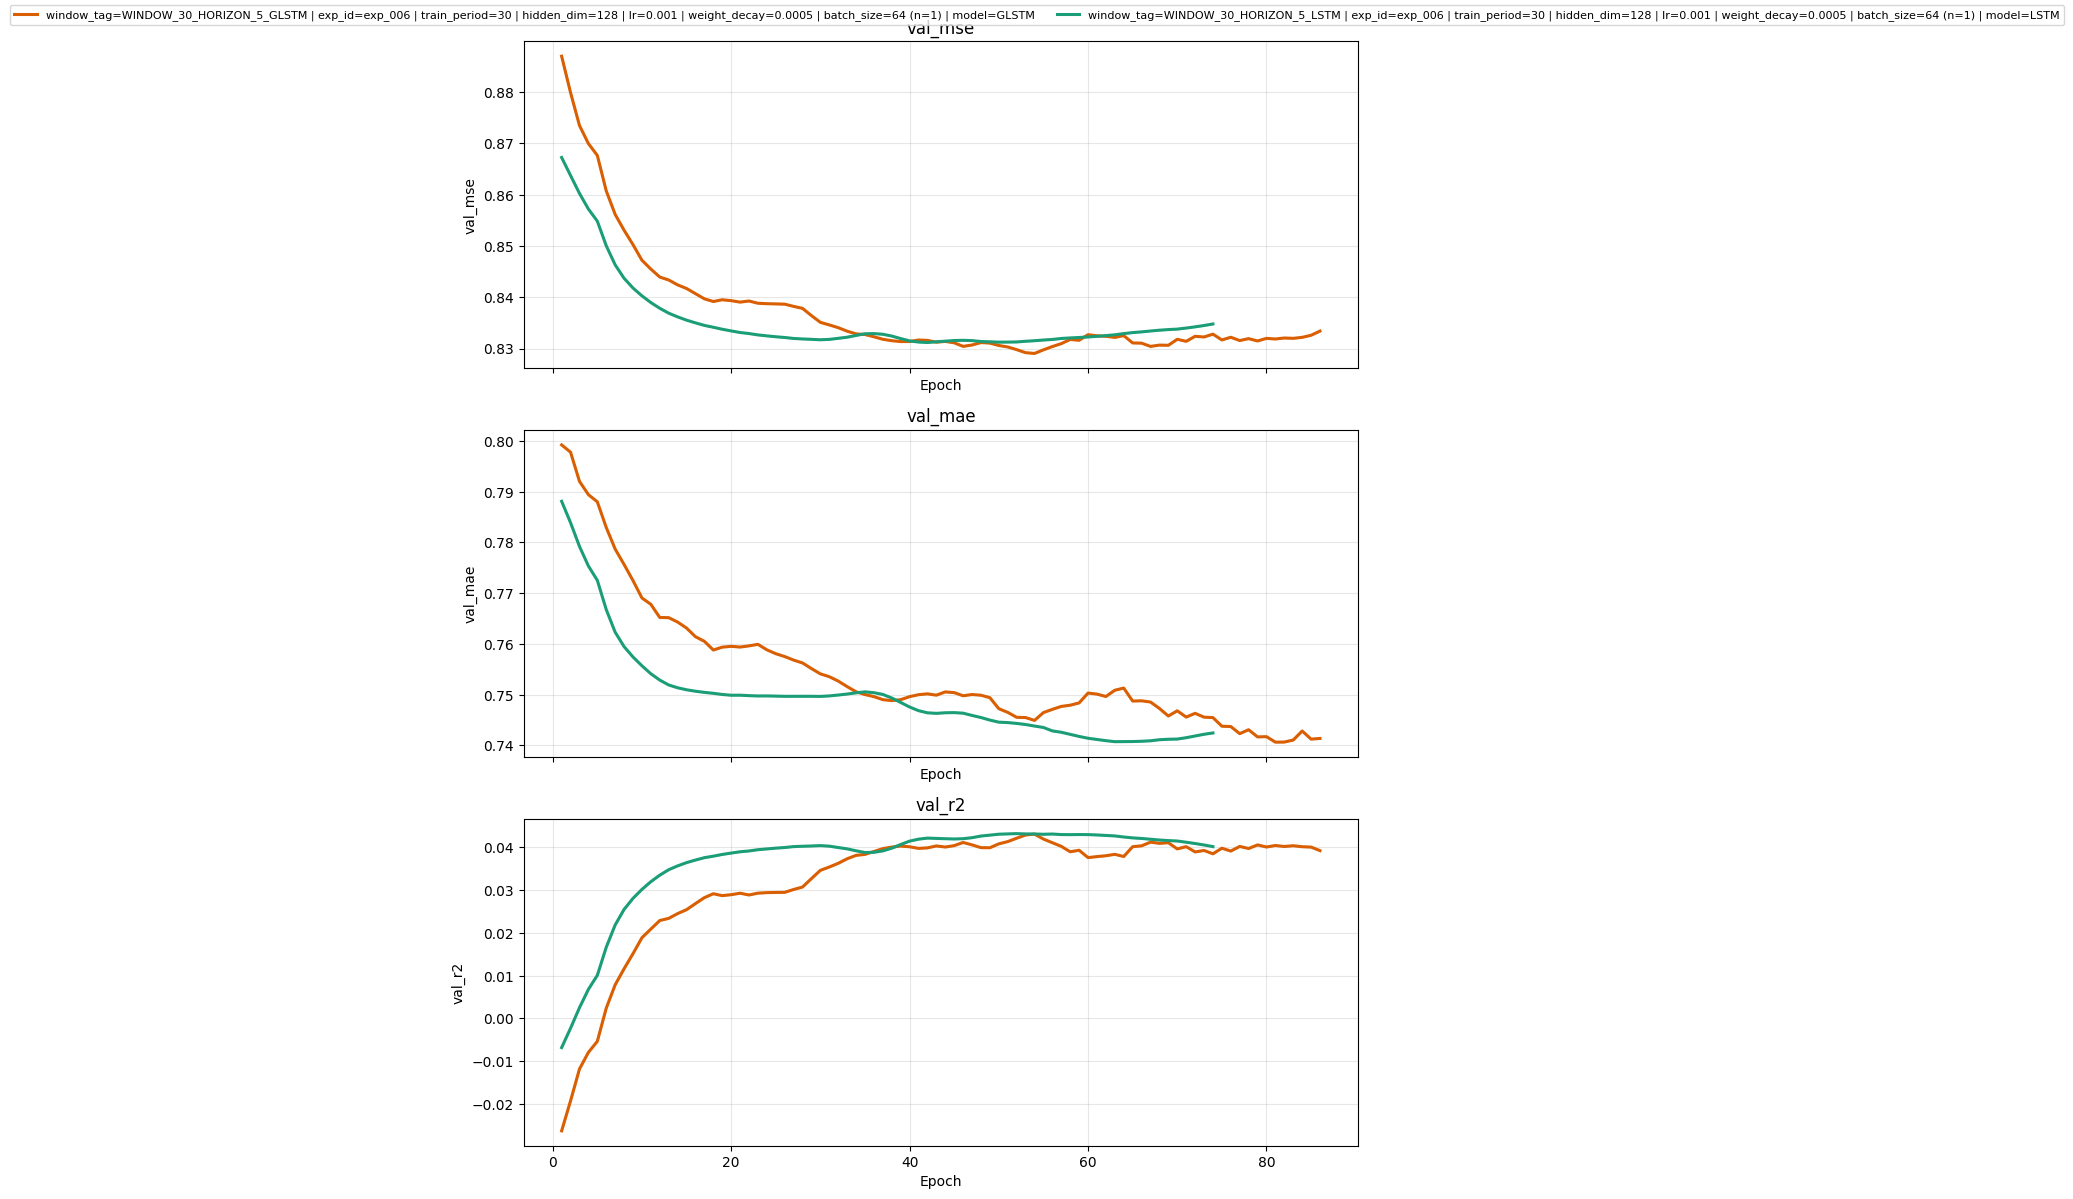

In [42]:
runs_df, tabela_runs, tabela_exp, _ = analisar_experimentos(
    root="C:\Local Reposity\LSTM-GNN\Experiments\comparing_only_128",
    smooth_window=5,
    show_individual=False
)

(<Figure size 8000x1000 with 1 Axes>,
 array([<Axes: title={'center': 'lr=0.001'}, xlabel='Epoch', ylabel='r2'>,
        <Axes: >, <Axes: >, <Axes: >], dtype=object))

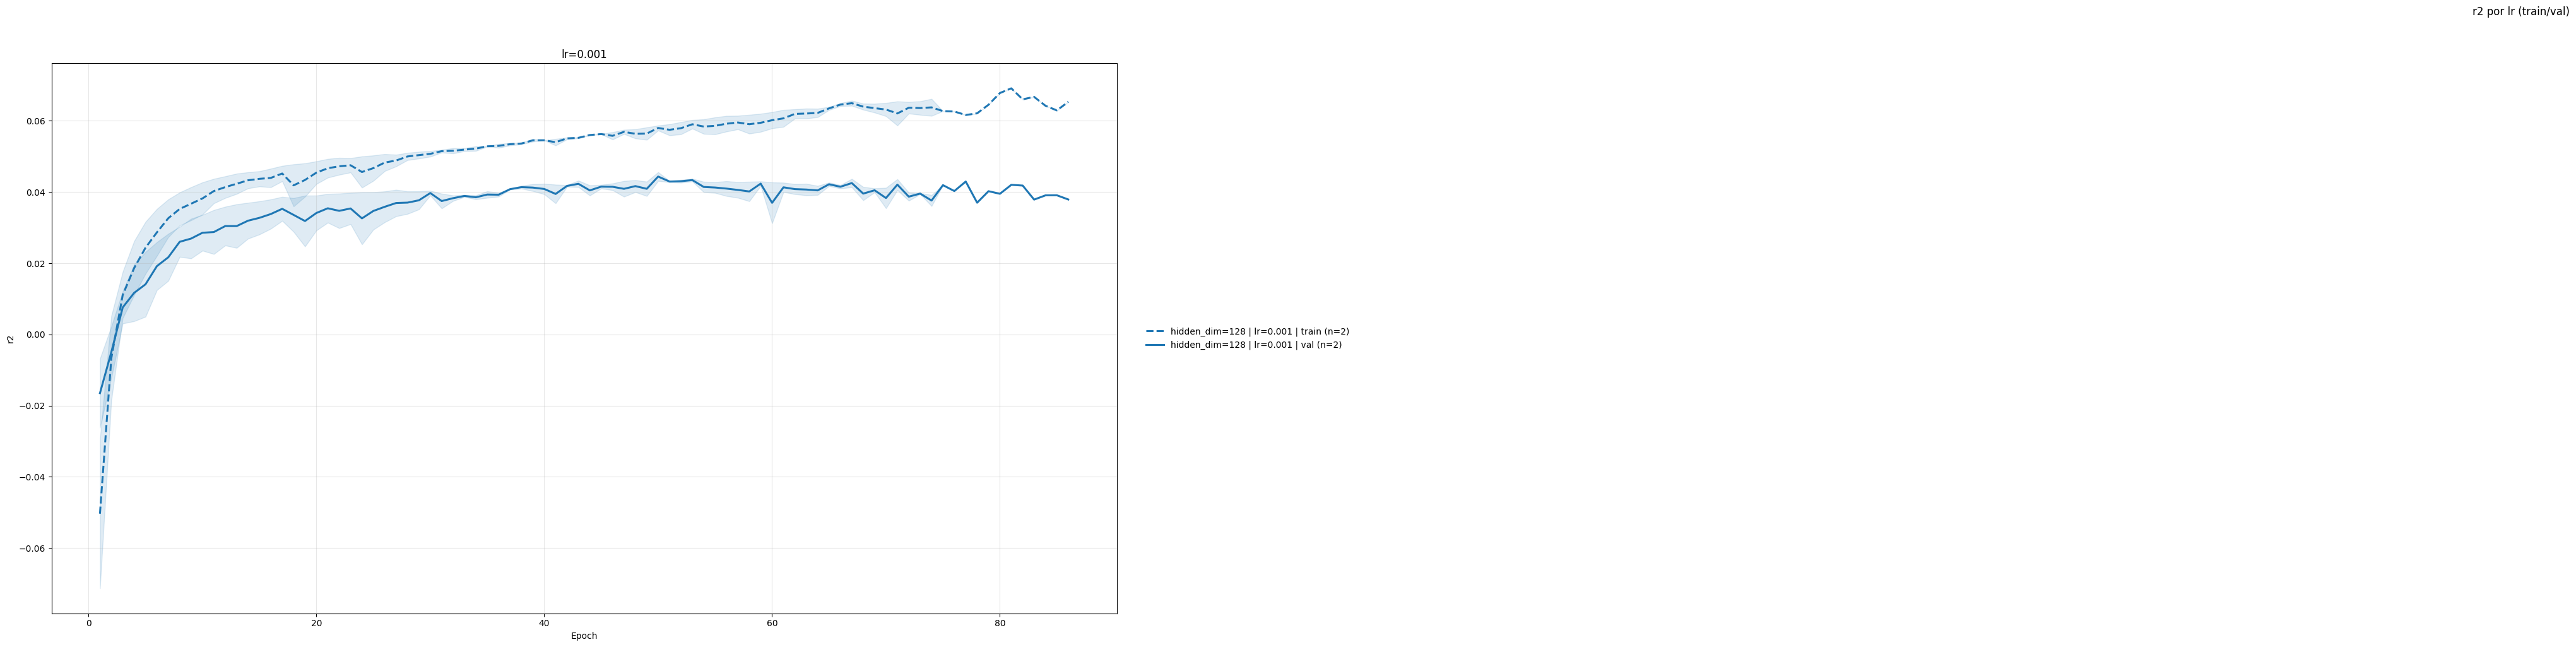

In [43]:
plot_por_hiperparametro_train_val_2(
    runs_df,
    param="lr",
    metric_base=("r2"),
    splits=("train", "val"),
    group_cols=("hidden_dim", "lr"),
    smooth_window=0,
    ncols=4
)

In [44]:
runs_df.head(n=20)

,summary_path,run_dir,window_tag,window_days,exp_id,model_tag,seed,train_period,hidden_dim,lr,...,best_val_loss,last_val_mse,last_val_mae,last_val_r2,last_val_mape,total_time_s,history,min_val_mse,min_val_mae,max_val_r2
0,C:\Local Reposity\LSTM-GNN\Experiments\compari...,C:\Local Reposity\LSTM-GNN\Experiments\compari...,WINDOW_30_HORIZON_5_GLSTM,None,exp_006,GLSTM,0,30,128,0.001,...,0.827831,0.835007,0.737105,0.037908,125.827079,1491.803773,"{'train_loss': [1.03022401034832, 0.9798665659...",0.827831,0.733209,0.045586
1,C:\Local Reposity\LSTM-GNN\Experiments\compari...,C:\Local Reposity\LSTM-GNN\Experiments\compari...,WINDOW_30_HORIZON_5_LSTM,None,exp_006,LSTM,0,30,128,0.001,...,0.831008,0.835560,0.742825,0.039160,124.559761,1227.897888,"{'train_loss': [0.9888236024058782, 0.95638570...",0.831008,0.740342,0.043438


(<Figure size 800x400 with 1 Axes>,
 array([<Axes: xlabel='Epoch', ylabel='r2'>], dtype=object))

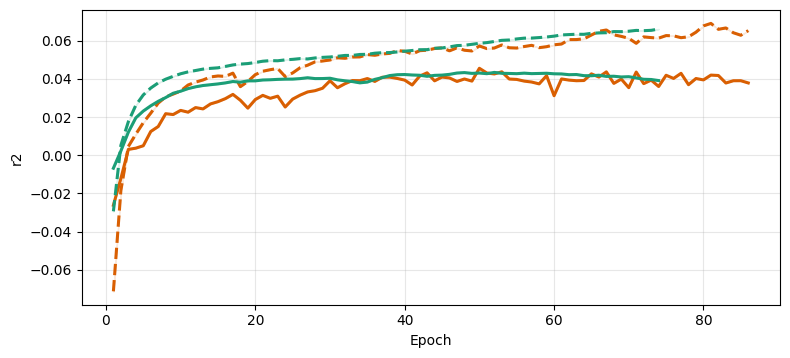

In [51]:
plot_por_hiperparametro_train_val(
    runs_df,
    param="hidden_dim",
    metric_base=("r2"),
    splits=("val", "train"),
    group_cols=("hidden_dim", "lr", "batch_size", "epoch"),
    smooth_window=0,
    ncols=1
)

In [30]:
import xarray as xr

rea = xr.open_dataset(r"C:\Climate Change Project\Utils\wind_data\era5_wind_14-25.nc")

In [31]:
print(rea.latitude.values)
print(rea.longitude.values)
print(rea.isobaricInhPa.values)
#d2m e t2m
#capturar entre 80-04

#u-v wind: níveis [850-500]
#capturar entre 80-13

[-25.   -25.25 -25.5  -25.75 -26.   -26.25 -26.5  -26.75 -27.   -27.25
 -27.5  -27.75 -28.   -28.25 -28.5  -28.75 -29.   -29.25 -29.5  -29.75
 -30.   -30.25 -30.5  -30.75 -31.   -31.25 -31.5  -31.75 -32.   -32.25
 -32.5  -32.75 -33.   -33.25 -33.5  -33.75 -34.   -34.25 -34.5  -34.75
 -35.  ]
[-60.   -59.75 -59.5  -59.25 -59.   -58.75 -58.5  -58.25 -58.   -57.75
 -57.5  -57.25 -57.   -56.75 -56.5  -56.25 -56.   -55.75 -55.5  -55.25
 -55.   -54.75 -54.5  -54.25 -54.   -53.75 -53.5  -53.25 -53.   -52.75
 -52.5  -52.25 -52.   -51.75 -51.5  -51.25 -51.   -50.75 -50.5  -50.25
 -50.   -49.75 -49.5  -49.25 -49.   -48.75 -48.5  -48.25 -48.   -47.75
 -47.5  -47.25 -47.   -46.75 -46.5  -46.25 -46.   -45.75 -45.5  -45.25
 -45.  ]
[850. 500.]


In [32]:
from 

SyntaxError: invalid syntax (681706079.py, line 1)